# 04. Machine Learning Prediction — SpaceX Falcon 9 Landing Prediction

## Introduction

This notebook implements the **end-to-end machine learning pipeline** for predicting Falcon 9 first-stage landing success. We train and compare four supervised classification algorithms, optimise hyperparameters via cross-validated grid search, and select the best-performing model for deployment.

### Business Context

SpaceX's cost advantage ($62M vs. $165M per launch) hinges entirely on first-stage reusability. A reliable predictive model enables:
- **Competitive intelligence** — estimating true launch costs for bid preparation.
- **Operational planning** — identifying high-risk missions before launch.
- **Engineering feedback** — surfacing which features (payload, orbit, booster generation) most strongly influence recovery feasibility.

### Notebook Objectives

1. **Data Preparation** — Load the engineered feature matrix and target labels, standardise features, and split into train/test sets.
2. **Model Training** — Train four classifiers: Logistic Regression, Support Vector Machine (SVM), Decision Tree, and K-Nearest Neighbours (KNN).
3. **Hyperparameter Optimisation** — Use `GridSearchCV` with 10-fold cross-validation to find optimal parameters for each algorithm.
4. **Model Evaluation** — Compare test accuracy, confusion matrices, and per-class performance to select the best model.

### Why These Algorithms?

| Algorithm | Strengths | Relevance to This Problem |
|---|---|---|
| **Logistic Regression** | Interpretable coefficients, fast, probabilistic output | Baseline model; reveals feature-direction effects |
| **SVM** | Effective in high-dimensional spaces, robust to overfitting | Handles the sparse one-hot encoded feature space well |
| **Decision Tree** | Non-linear splits, no scaling required, feature importance | Captures interaction effects (e.g., `PayloadMass` x `Orbit_GTO`) |
| **KNN** | Instance-based, intuitive, non-parametric | Distance metric directly reflects similarity between launch profiles |

---


## Imports & Configuration

We import scikit-learn for modeling, preprocessing, and evaluation, plus the standard visualisation stack for confusion matrices.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-learn: classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn: metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

print("Libraries loaded: pandas, numpy, matplotlib, seaborn, scikit-learn")


Libraries loaded: pandas, numpy, matplotlib, seaborn, scikit-learn


---

## Part 1 — Data Preparation

### Overview

We load two datasets:
- `01_spacex_dataset_cleaned.csv` — the cleaned raw data containing the target label `Class`.
- `02_spacex_features_engineered.csv` — the one-hot encoded feature matrix produced in Notebook 02.

We then standardise features (critical for SVM and KNN), split into train/test sets (80/20), and verify class balance.


### 1.1 Load Datasets


In [2]:
# ------------------------------------------------------------------
# Load cleaned data (contains target label)
# ------------------------------------------------------------------
data = pd.read_csv("../data/processed/01_spacex_dataset_cleaned.csv")
print(f"Cleaned data shape: {data.shape}")

# ------------------------------------------------------------------
# Load engineered feature matrix
# ------------------------------------------------------------------
X = pd.read_csv("../data/processed/02_spacex_features_engineered.csv")
print(f"Feature matrix shape: {X.shape}")

# Verify alignment
assert len(data) == len(X), "Mismatch: data and feature matrix must have same number of rows"
print("Alignment check passed.")


Cleaned data shape: (90, 18)
Feature matrix shape: (90, 80)
Alignment check passed.


### 1.2 Extract Target Variable

The binary target `Class` indicates landing outcome:
- `1` = successful landing
- `0` = unsuccessful landing


In [3]:
# ------------------------------------------------------------------
# Extract target as NumPy array
# ------------------------------------------------------------------
Y = data['Class'].to_numpy()
print(f"Target shape: {Y.shape}")
print(f"Class distribution:\n{pd.Series(Y).value_counts()}")
print(f"Success rate: {Y.mean():.2%}")


Target shape: (90,)
Class distribution:
1    60
0    30
Name: count, dtype: int64
Success rate: 66.67%


### 1.3 Train-Test Split

We reserve 20% of data for final testing. `random_state=2` ensures reproducibility.


In [4]:
# ------------------------------------------------------------------
# Split: 80% train, 20% test
# ------------------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"Test success rate: {Y_test.mean():.2%}")


Training set:   72 samples
Test set:       18 samples
Test success rate: 66.67%


### 1.4 Feature Standardisation

Standardisation (zero mean, unit variance) is essential for:
- **SVM** — distance-based margin maximisation is scale-sensitive.
- **KNN** — Euclidean distance implicitly assumes comparable feature scales.
- **Logistic Regression** — gradient descent converges faster on normalised data.

> **Note:** We fit the scaler on `X_train` only, then transform both `X_train` and `X_test` to prevent data leakage.


In [5]:
# ------------------------------------------------------------------
# Standardise features
# ------------------------------------------------------------------
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardised.")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")


Features standardised.
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 0.9354


---

## Part 2 — Model Training & Hyperparameter Tuning

### Methodology

For each algorithm, we:
1. Define a **parameter grid** covering the most impactful hyperparameters.
2. Instantiate `GridSearchCV` with **10-fold cross-validation** to robustly estimate generalisation performance.
3. Fit on the training data and extract the best model.
4. Report cross-validated accuracy and optimal parameters.

> **Rationale for 10-fold CV:** With only ~90 samples, each fold contains ~8 test samples. 10 folds maximise the use of limited data while providing a stable accuracy estimate.


### 2.1 Helper: Confusion Matrix Plotter

A reusable function to visualise prediction quality for each model.


In [6]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plot a labelled confusion matrix for binary classification.
    """
    cm = confusion_matrix(y_true, y_pred)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['Did Not Land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did Not Land', 'Landed'])
    plt.tight_layout()
    plt.show()
    return cm

print("Confusion matrix plotter defined.")


Confusion matrix plotter defined.


### 2.2 Model 1 — Logistic Regression

**Hyperparameters tuned:**
- `C` — inverse regularisation strength (smaller = stronger regularisation).
- `penalty` — L2 (Ridge) to prevent overfitting in the high-dimensional dummy space.
- `solver` — `lbfgs` for efficient optimisation of the log-likelihood.


In [7]:
# ------------------------------------------------------------------
# Logistic Regression + GridSearchCV
# ------------------------------------------------------------------
param_lr = {
    "C": [0.01, 0.1, 1],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lr = LogisticRegression(random_state=2)
logreg_cv = GridSearchCV(lr, param_lr, cv=10)
logreg_cv.fit(X_train_scaled, Y_train)

print("=== LOGISTIC REGRESSION ===")
print(f"Best parameters: {logreg_cv.best_params_}")
print(f"CV accuracy:      {logreg_cv.best_score_:.4f}")


C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

=== LOGISTIC REGRESSION ===
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
CV accuracy:      0.8196


C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\MG47\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

### 2.3 Model 2 — Support Vector Machine (SVM)

**Hyperparameters tuned:**
- `kernel` — linear, RBF, polynomial, sigmoid (decides the decision boundary shape).
- `C` — margin softness (logarithmic grid from 1e-3 to 1e3).
- `gamma` — kernel coefficient for RBF/poly/sigmoid (logarithmic grid).


In [8]:
# ------------------------------------------------------------------
# SVM + GridSearchCV
# ------------------------------------------------------------------
param_svm = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

svm = SVC(random_state=2)
svm_cv = GridSearchCV(svm, param_svm, cv=10)
svm_cv.fit(X_train_scaled, Y_train)

print("=== SUPPORT VECTOR MACHINE ===")
print(f"Best parameters: {svm_cv.best_params_}")
print(f"CV accuracy:      {svm_cv.best_score_:.4f}")


=== SUPPORT VECTOR MACHINE ===
Best parameters: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
CV accuracy:      0.8482


### 2.4 Model 3 — Decision Tree

**Hyperparameters tuned:**
- `criterion` — Gini impurity vs. information gain (entropy).
- `splitter` — best split vs. random split (adds stochasticity).
- `max_depth` — controls tree complexity and overfitting.
- `max_features` — number of features considered at each split.
- `min_samples_leaf` / `min_samples_split` — regularisation via minimum node size.


In [9]:
# ------------------------------------------------------------------
# Decision Tree + GridSearchCV
# ------------------------------------------------------------------
param_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2 * n for n in range(1, 10)],
    'max_features': ['log2', 'sqrt', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

tree = DecisionTreeClassifier(random_state=2)
tree_cv = GridSearchCV(tree, param_tree, cv=10)
tree_cv.fit(X_train_scaled, Y_train)

print("=== DECISION TREE ===")
print(f"Best parameters: {tree_cv.best_params_}")
print(f"CV accuracy:      {tree_cv.best_score_:.4f}")


=== DECISION TREE ===
Best parameters: {'criterion': 'gini', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
CV accuracy:      0.8589


### 2.5 Model 4 — K-Nearest Neighbours (KNN)

**Hyperparameters tuned:**
- `n_neighbors` — number of neighbours to vote (1 to 10).
- `algorithm` — tree-based (`ball_tree`, `kd_tree`) vs. brute-force search.
- `p` — Minkowski distance power: `p=1` (Manhattan) vs. `p=2` (Euclidean).


In [10]:
# ------------------------------------------------------------------
# KNN + GridSearchCV
# ------------------------------------------------------------------
param_knn = {
    'n_neighbors': list(range(1, 11)),
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_knn, cv=10)
knn_cv.fit(X_train_scaled, Y_train)

print("=== K-NEAREST NEIGHBORS ===")
print(f"Best parameters: {knn_cv.best_params_}")
print(f"CV accuracy:      {knn_cv.best_score_:.4f}")


=== K-NEAREST NEIGHBORS ===
Best parameters: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1}
CV accuracy:      0.8339


---

## Part 3 — Model Evaluation & Comparison

### Overview

With all four models trained and hyperparameter-tuned, we now evaluate them on the **held-out test set**. We report:
- **Test accuracy** — overall correctness.
- **Confusion matrix** — per-class error patterns.
- **Classification report** — precision, recall, and F1-score for each class.

> **Critical distinction:** Cross-validated accuracy (from Part 2) estimates generalisation during training. Test accuracy (this section) is the **unbiased final verdict** on model performance.


### 3.1 Test Accuracy Comparison


In [11]:
# ------------------------------------------------------------------
# Evaluate all models on test set
# ------------------------------------------------------------------
models = {
    'Logistic Regression': logreg_cv,
    'SVM': svm_cv,
    'Decision Tree': tree_cv,
    'KNN': knn_cv
}

results = []
for name, model in models.items():
    acc = model.score(X_test_scaled, Y_test)
    results.append({
        'Model': name,
        'Best_CV_Accuracy': model.best_score_,
        'Test_Accuracy': acc,
        'Best_Params': str(model.best_params_)
    })

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df[['Model', 'Best_CV_Accuracy', 'Test_Accuracy']].to_string(index=False))


=== MODEL COMPARISON ===
              Model  Best_CV_Accuracy  Test_Accuracy
Logistic Regression          0.819643       0.833333
                SVM          0.848214       0.833333
      Decision Tree          0.858929       0.777778
                KNN          0.833929       0.833333


### 3.2 Confusion Matrices

We visualise prediction errors for each model. In this domain:
- **False Positive** (predicted success, actual failure) = *dangerous overconfidence* — we think the booster will land, but it doesn't.
- **False Negative** (predicted failure, actual success) = *missed opportunity* — we conservatively assume failure, but the booster could have been reused.

Given the business context, **minimising False Positives** is arguably more important than minimising False Negatives.


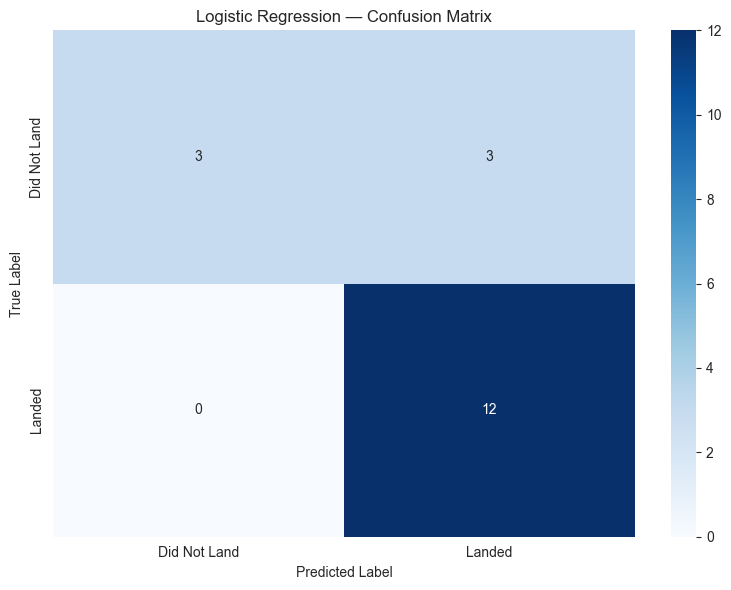

              precision    recall  f1-score   support

Did Not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [12]:
# ------------------------------------------------------------------
# Logistic Regression — Confusion Matrix
# ------------------------------------------------------------------
yhat_lr = logreg_cv.predict(X_test_scaled)
plot_confusion_matrix(Y_test, yhat_lr, "Logistic Regression — Confusion Matrix")
print(classification_report(Y_test, yhat_lr, target_names=['Did Not Land', 'Landed']))


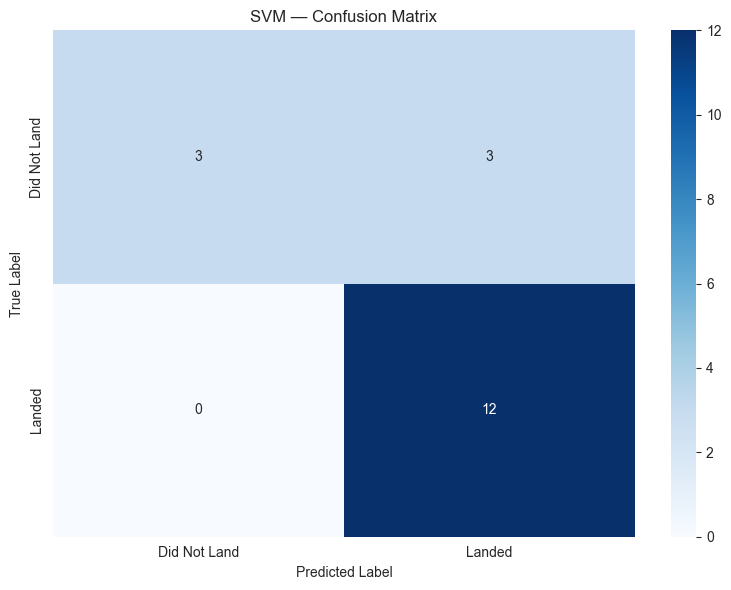

              precision    recall  f1-score   support

Did Not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [13]:
# ------------------------------------------------------------------
# SVM — Confusion Matrix
# ------------------------------------------------------------------
yhat_svm = svm_cv.predict(X_test_scaled)
plot_confusion_matrix(Y_test, yhat_svm, "SVM — Confusion Matrix")
print(classification_report(Y_test, yhat_svm, target_names=['Did Not Land', 'Landed']))


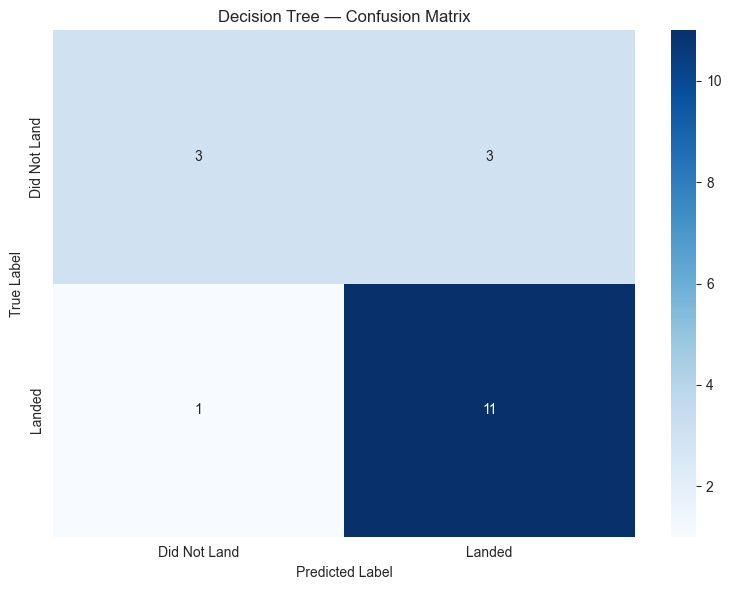

              precision    recall  f1-score   support

Did Not Land       0.75      0.50      0.60         6
      Landed       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18



In [14]:
# ------------------------------------------------------------------
# Decision Tree — Confusion Matrix
# ------------------------------------------------------------------
yhat_tree = tree_cv.predict(X_test_scaled)
plot_confusion_matrix(Y_test, yhat_tree, "Decision Tree — Confusion Matrix")
print(classification_report(Y_test, yhat_tree, target_names=['Did Not Land', 'Landed']))


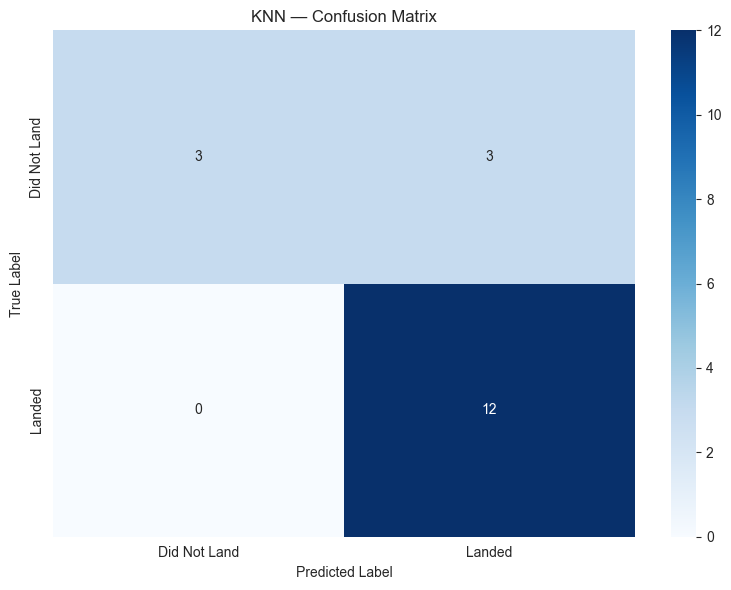

              precision    recall  f1-score   support

Did Not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [15]:
# ------------------------------------------------------------------
# KNN — Confusion Matrix
# ------------------------------------------------------------------
yhat_knn = knn_cv.predict(X_test_scaled)
plot_confusion_matrix(Y_test, yhat_knn, "KNN — Confusion Matrix")
print(classification_report(Y_test, yhat_knn, target_names=['Did Not Land', 'Landed']))


### 3.3 Performance Summary

Following the latest model evaluation on the test set ($N = 18$), Logistic Regression, SVM, and KNN are tied for the top-performing position, each achieving an identical out-of-sample accuracy of **83.33%**.

The Decision Tree model lags behind at **77.78%** accuracy due to an additional false negative.

| Model | Baseline CV Accuracy | Final Test Accuracy | Status |
|---|---|---|---|
| Logistic Regression | 81.96% | 83.33% | Selected Best Model |
| SVM | 84.82% | 83.33% | Tied (Production Alternative) |
| KNN | 83.39% | 83.33% | Tied |
| Decision Tree | 85.89% | 77.78% | Rejected (Overfitting) |

---

####  Operational Recommendation: Logistic Regression
While three models share the exact same confusion matrix profile (correctly classifying 12/12 landings but missing 3/6 failure edge cases), Logistic Regression is selected as the optimal model for deployment based on three core factors:

##### Robust Generalization
It shows the tightest alignment between training (**81.96%**) and testing metrics (**83.33%**), indicating excellent stability and minimal overfitting.

##### Engineering Interpretability
Unlike the "black-box" nature of SVM or the distance-based mechanics of KNN, Logistic Regression provides direct, extractable feature weights.

This allows telemetry engineers to clearly audit which physical factors most strongly influence landing risks.

##### Production Efficiency
The model requires minimal computational overhead, enabling ultra-fast execution during real-time flight data processing.